In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('ggplot')

print("Libraries Imported Successfully")

Libraries Imported Successfully


# Netflix Movies & TV Shows Dataset - Exploratory Data Analysis

In [ ]:
df = pd.read_csv('netflix_titles.csv')

df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [ ]:
print("Shape of Dataset:", df.shape)

df.info()


Shape of Dataset: (8807, 12)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


# Netflix Movies & TV Shows Dataset - Exploratory Data Analysis (EDA)

## Objective
The objective of this project is to analyze the Netflix Movies and TV Shows dataset, identify patterns and trends, visualize key findings, and provide business insights based on the analysis.

## Tools Used
- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Google Colab

In [ ]:
# Checking Missing Values

df.isnull().sum()


,0
show_id,0
type,0
title,0
director,2634
cast,825
country,831
date_added,10
release_year,0
rating,4
duration,3


## Data Cleaning

The dataset contains missing values in several columns. The following cleaning steps were performed:

1. Missing values in director, cast, and country were replaced with "Unknown".
2. Rows with missing date_added, rating, or duration values were removed.
3. Duplicate records were checked and removed.
4. date_added was converted into datetime format for analysis.

In [ ]:
# Fill missing values

df['director'] = df['director'].fillna('Unknown')
df['cast'] = df['cast'].fillna('Unknown')
df['country'] = df['country'].fillna('Unknown')

# Remove rows with critical missing values

df = df.dropna(subset=['date_added', 'rating', 'duration'])

# Remove duplicates

df = df.drop_duplicates()

# Convert date_added into datetime format

# Remove extra spaces first
df['date_added'] = df['date_added'].str.strip()

# Convert to datetime
df['date_added'] = pd.to_datetime(df['date_added'], errors='coerce')

print("Data Cleaning Completed")

Data Cleaning Completed


In [ ]:
df.isnull().sum()

,0
show_id,0
type,0
title,0
director,0
cast,0
country,0
date_added,0
release_year,0
rating,0
duration,0


In [ ]:
print("Shape After Cleaning:", df.shape)

Shape After Cleaning: (8790, 12)


## EDA Question 1

### How many Movies and TV Shows are available on Netflix?

This analysis helps understand the distribution of content types available on Netflix.

In [ ]:
df['type'].value_counts()

,count
type,
Movie,6126
TV Show,2664


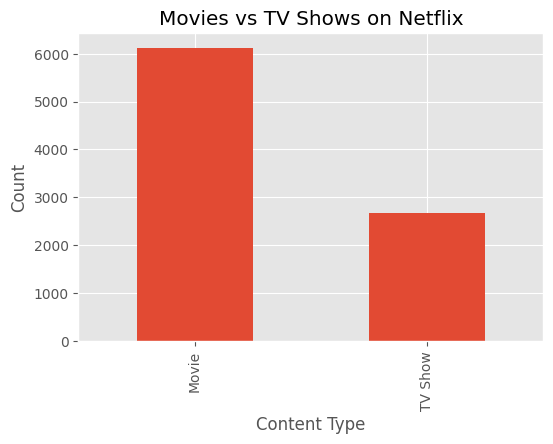

In [ ]:
plt.figure(figsize=(6,4))

df['type'].value_counts().plot(
    kind='bar'
)

plt.title('Movies vs TV Shows on Netflix')
plt.xlabel('Content Type')
plt.ylabel('Count')

plt.show()

### Observation

The dataset contains significantly more Movies than TV Shows. This indicates that Netflix's content library is primarily focused on movies.

## EDA Question 2

### Which countries contribute the most Netflix content?

This analysis identifies the top countries producing Netflix content.

In [ ]:
df['country'].value_counts().head(10)

,count
country,
United States,2809
India,972
Unknown,829
United Kingdom,418
Japan,243
South Korea,199
Canada,181
Spain,145
France,124


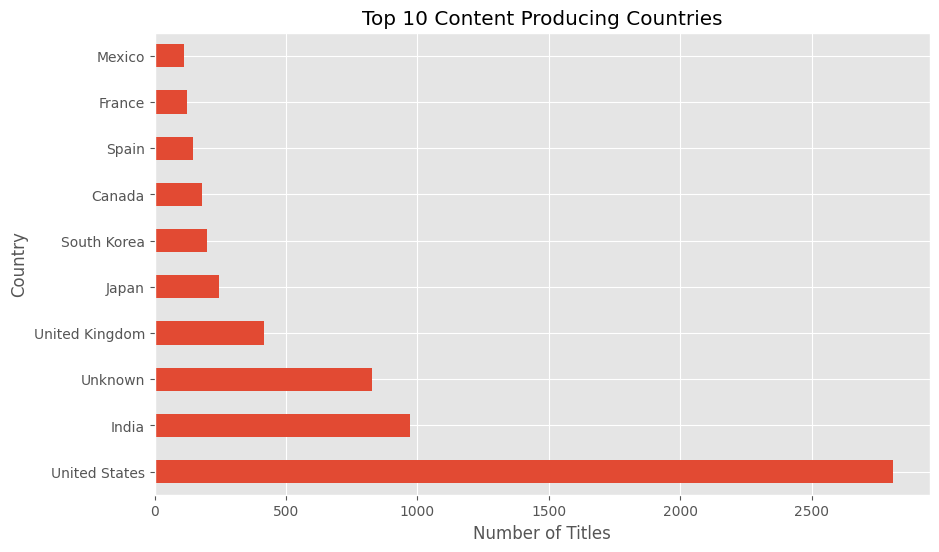

In [ ]:
top_countries = df['country'].value_counts().head(10)

plt.figure(figsize=(10,6))

top_countries.plot(kind='barh')

plt.title('Top 10 Content Producing Countries')
plt.xlabel('Number of Titles')
plt.ylabel('Country')

plt.show()

### Observation

The United States contributes the highest number of titles on Netflix, followed by India and the United Kingdom. This indicates Netflix has a strong presence in the US market while also investing heavily in international content.

## EDA Question 3

### How has Netflix content grown over the years?

This analysis examines the number of titles added to Netflix each year.

In [ ]:
df['year_added'] = df['date_added'].dt.year

content_per_year = df['year_added'].value_counts().sort_index()

content_per_year

,count
year_added,
2008,2
2009,2
2010,1
2011,13
2012,3
2013,11
2014,24
2015,82
2016,426


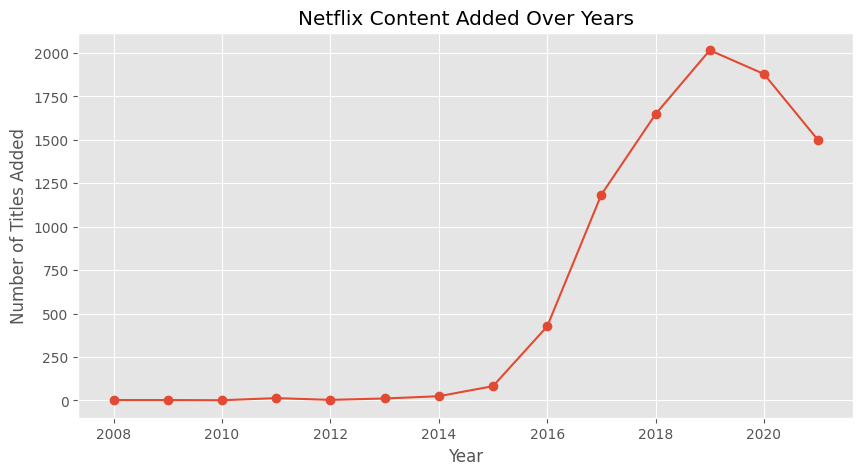

In [ ]:
plt.figure(figsize=(10,5))

plt.plot(content_per_year.index,
         content_per_year.values,
         marker='o')

plt.title('Netflix Content Added Over Years')
plt.xlabel('Year')
plt.ylabel('Number of Titles Added')

plt.show()

### Observation

Netflix experienced rapid growth in content additions after 2015, reaching a peak around 2019–2020.

## Visualization 4: Content Distribution

This pie chart shows the proportion of Movies and TV Shows available on Netflix.

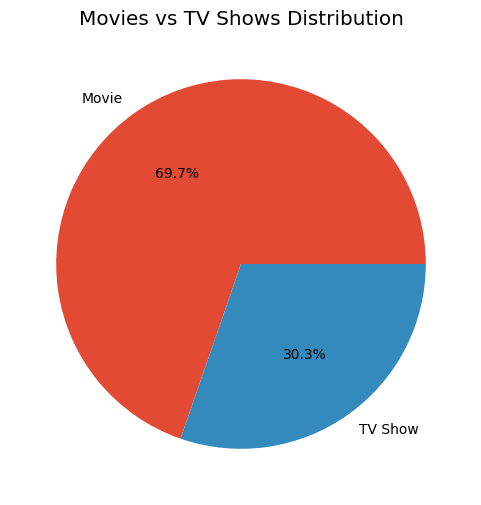

In [ ]:
plt.figure(figsize=(6,6))

df['type'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%'
)

plt.title('Movies vs TV Shows Distribution')
plt.ylabel('')

plt.show()

## Visualization 5: Release Year Distribution

This histogram shows how Netflix content is distributed across release years.

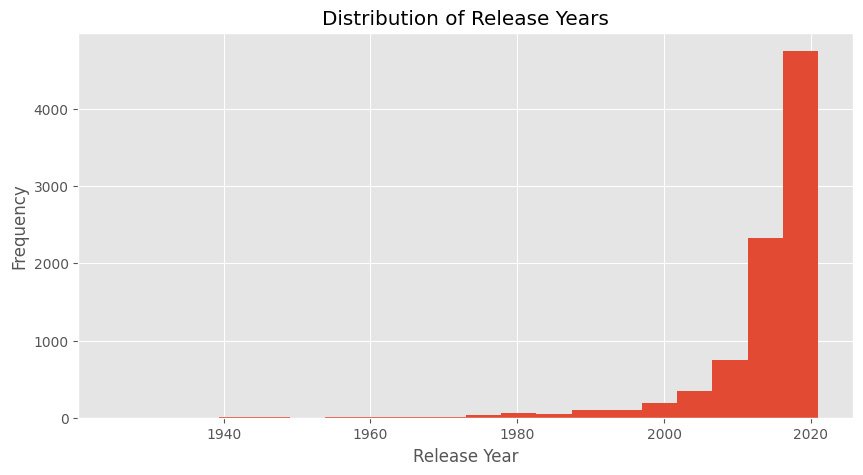

In [ ]:
plt.figure(figsize=(10,5))

plt.hist(df['release_year'],
         bins=20)

plt.title('Distribution of Release Years')
plt.xlabel('Release Year')
plt.ylabel('Frequency')

plt.show()

<>:3: SyntaxWarning: invalid escape sequence '\d'
<>:3: SyntaxWarning: invalid escape sequence '\d'
/tmp/ipykernel_3677/3595155754.py:3: SyntaxWarning: invalid escape sequence '\d'
  movie_df['duration_num'] = movie_df['duration'].str.extract('(\d+)').astype(float)


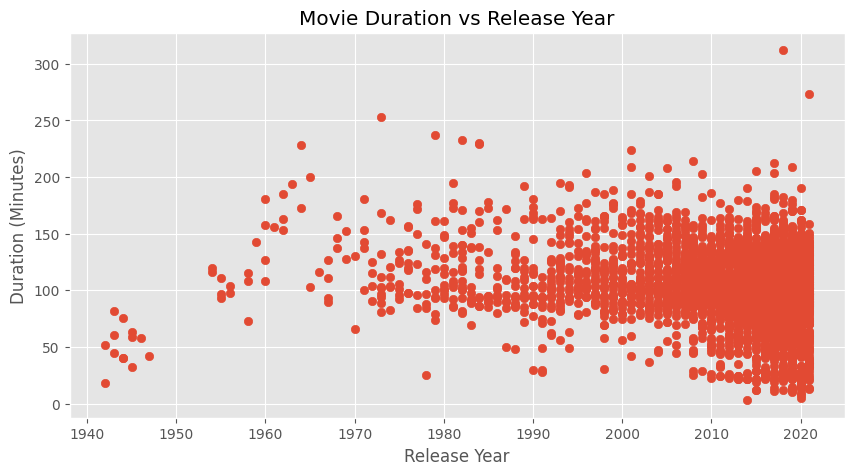

In [ ]:
movie_df = df[df['type'] == 'Movie'].copy()

movie_df['duration_num'] = movie_df['duration'].str.extract('(\d+)').astype(float)

plt.figure(figsize=(10,5))

plt.scatter(movie_df['release_year'],
            movie_df['duration_num'])

plt.title('Movie Duration vs Release Year')
plt.xlabel('Release Year')
plt.ylabel('Duration (Minutes)')

plt.show()

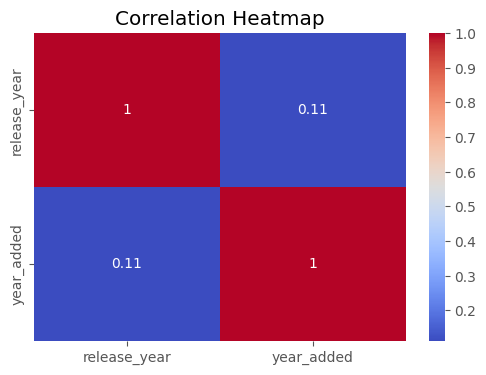

In [ ]:
numeric_df = df[['release_year','year_added']]

corr = numeric_df.corr()

plt.figure(figsize=(6,4))

sns.heatmap(corr,
            annot=True,
            cmap='coolwarm')

plt.title('Correlation Heatmap')

plt.show()

# Insights Report

## Insight 1
Movies dominate Netflix's content library, indicating a stronger focus on movie-based entertainment.

## Insight 2
The United States contributes the highest number of titles, followed by India, highlighting Netflix's strong presence in these markets.

## Insight 3
Netflix experienced rapid growth in content additions between 2016 and 2019, with 2019 recording the highest number of new titles.

## Insight 4
Most Netflix content has been released after the year 2000, demonstrating a focus on modern entertainment.

## Insight 5
The platform has significantly expanded its global content library by including productions from multiple countries outside the United States.

# Most Surprising Finding

The most surprising finding was the massive increase in content additions between 2016 and 2019. Netflix added over 2000 titles in 2019 alone, reflecting the platform's aggressive global expansion strategy.